# California Housing Price Prediction — K-Nearest Neighbors Regressor
### Domain: Geospatial & Macroeconomic Real Estate Valuation | Algorithm: K-Nearest Neighbors Regressor (`KNeighborsRegressor`)

---

### Executive Overview & Mathematical Rationale
1. **The Spatial Proximity Hypothesis**: Unlike linear parametric models that assume flat hyperplanes, real estate value is profoundly non-linear and local. Two identical houses have vastly different market values depending on micro-neighborhood dynamics.
2. **K-Nearest Neighbors Advantage**: By utilizing spatial coordinates (`Latitude`, `Longitude`) alongside economic indicators (`MedInc`), KNN naturally interpolates local pricing micro-climates without requiring manual spatial polynomial feature engineering.
3. **The Absolute Necessity of Feature Scaling**: In raw coordinates, `Population` ranges into thousands while `MedInc` ranges between 0.5 and 15. Without geometric normalization (`StandardScaler`), population distances dwarf median income, destroying distance geometry.
4. **Zero-Leakage Architecture**: Strict execution of the 13-step enterprise standard, ensuring cross-validation and feature scaling parameters are fitted exclusively on training folds.


In [1]:
# ==============================================================================
# 🌐 STEP 1: UNIVERSAL ENTERPRISE LIBRARIES IMPORT
# ==============================================================================
import os
import sys
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

print("✅ STEP 1: Enterprise Libraries Imported Successfully.")


✅ STEP 1: Enterprise Libraries Imported Successfully.


In [2]:
# ==============================================================================
# 🌐 STEP 2: ROBUST DATA INGESTION & 3-SECOND HEALTH AUDIT
# ==============================================================================
def load_and_audit_dataset(file_path):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"🚨 Dataset not found at: {path.resolve()}")
        
    try:
        df = pd.read_csv(path, engine='python', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(path, engine='python', encoding='latin-1')
        
    print("=" * 70)
    print(f"📊 DATASET INGESTION HEALTH AUDIT: {path.name}")
    print("=" * 70)
    print(f"  • Shape (Rows, Columns)   : {df.shape[0]:,} rows | {df.shape[1]} columns")
    print(f"  • In-Memory Footprint     : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"  • Duplicate Observations  : {df.duplicated().sum():,} rows")
    print(f"  • Total Missing Elements  : {df.isnull().sum().sum():,} cells")
    print("=" * 70)
    
    return df

data_file = "data/california_housing/california_housing.csv"
df = load_and_audit_dataset(data_file)
display(df.head(5))


📊 DATASET INGESTION HEALTH AUDIT: california_housing.csv
  • Shape (Rows, Columns)   : 20,640 rows | 9 columns
  • In-Memory Footprint     : 1.42 MB
  • Duplicate Observations  : 0 rows
  • Total Missing Elements  : 0 cells


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# ==============================================================================
# 🧼 STEP 2B: ENTERPRISE ADVANCED DATA SANITIZATION
# ==============================================================================
def sanitize_dataset(df, user_drop_cols=None):
    if user_drop_cols:
        existing = [c for c in user_drop_cols if c in df.columns]
        if existing:
            df = df.drop(columns=existing)
            print(f"🗑️ Dropped non-predictive identifier columns: {existing}")
    df.columns = [c.strip() for c in df.columns]
    print(f"✅ Data Sanitization complete. Cleaned shape: {df.shape}")
    return df

df = sanitize_dataset(df)


✅ Data Sanitization complete. Cleaned shape: (20640, 9)


In [4]:
# ==============================================================================
# 🌐 STEP 3: AUTOMATED 3-BUCKET FEATURE SEGREGATOR
# ==============================================================================
def segregate_features(df, target_col, drop_cols=None, cardinality_threshold=15):
    if drop_cols is None:
        drop_cols = []
    all_features = [col for col in df.columns if col != target_col and col not in drop_cols]
    continuous_features = []
    categorical_features = []
    
    for col in all_features:
        if pd.api.types.is_numeric_dtype(df[col]):
            if df[col].nunique() <= cardinality_threshold and not pd.api.types.is_float_dtype(df[col]):
                categorical_features.append(col)
            else:
                continuous_features.append(col)
        else:
            categorical_features.append(col)
            
    print("=" * 70)
    print("🌐 STEP 3: AUTOMATED FEATURE BUCKET AUDIT")
    print("=" * 70)
    print(f"  • Target Column           : '{target_col}'")
    print(f"  • Continuous Features ({len(continuous_features)}) : {continuous_features}")
    print(f"  • Categorical Features ({len(categorical_features)}) : {categorical_features}")
    print(f"  • Dropped Features ({len(drop_cols)})     : {drop_cols}")
    print("=" * 70)
    
    return continuous_features, categorical_features

target_col = "MedHouseVal"
cont_cols, cat_cols = segregate_features(df, target_col=target_col)


🌐 STEP 3: AUTOMATED FEATURE BUCKET AUDIT
  • Target Column           : 'MedHouseVal'
  • Continuous Features (8) : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  • Categorical Features (0) : []
  • Dropped Features (0)     : []


In [5]:
# ==============================================================================
# 🌐 STEP 4: DATA HYGIENE AUDIT (DUPLICATES & MISSINGNESS PROFILER)
# ==============================================================================
def audit_and_clean_hygiene(df, drop_duplicates=True):
    print("=" * 70)
    print("🧹 STEP 4: DATA HYGIENE AUDIT")
    print("=" * 70)
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        print(f"⚠️ Found {dup_count:,} duplicate rows.")
        if drop_duplicates:
            df = df.drop_duplicates().reset_index(drop=True)
            print(f"   -> Dropped duplicates. New shape: {df.shape}")
    else:
        print("✅ Zero duplicate rows found.")
        
    missing = df.isnull().sum()
    missing_report = missing[missing > 0]
    if len(missing_report) > 0:
        print(f"⚠️ Missing Value Summary:\n{missing_report}")
    else:
        print("✅ Complete dataset: Zero missing cells detected across all columns.")
    print("=" * 70)
    return df

df = audit_and_clean_hygiene(df)


🧹 STEP 4: DATA HYGIENE AUDIT


✅ Zero duplicate rows found.
✅ Complete dataset: Zero missing cells detected across all columns.


In [6]:
# ==============================================================================
# 🌐 STEP 5: ENTERPRISE TRAIN-TEST SPLITTER (ZERO DATA LEAKAGE + TARGET GUARD)
# ==============================================================================
def perform_zero_leakage_split(df, target_col, drop_cols=None, is_classification=False, apply_log_target=False, test_size=0.20, random_state=42):
    if drop_cols is None:
        drop_cols = []
        
    if df[target_col].isnull().any():
        n_dropped = df[target_col].isnull().sum()
        print(f"⚠️ Dropping {n_dropped:,} rows where target '{target_col}' is NaN!")
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col]
    
    for c in X.select_dtypes(exclude=[np.number]).columns:
        X[c] = X[c].fillna('Missing').astype(str)
        
    if not is_classification and apply_log_target:
        print("📈 Target Transformation: Applying np.log1p to alleviate skewness.")
        y = np.log1p(y)
        
    stratify = y if is_classification else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify
    )
    
    print("=" * 70)
    print("🔒 STEP 5: ZERO DATA LEAKAGE PARTITION REPORT")
    print("=" * 70)
    print(f"  • Train Partition Shape : X_train: {X_train.shape} | y_train: {y_train.shape}")
    print(f"  • Test Partition Shape  : X_test: {X_test.shape}  | y_test: {y_test.shape}")
    print(f"  • Test Ratio Target     : {test_size*100:.1f}%")
    print("=" * 70)
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = perform_zero_leakage_split(
    df, target_col=target_col, apply_log_target=False, test_size=0.20, random_state=42
)


🔒 STEP 5: ZERO DATA LEAKAGE PARTITION REPORT
  • Train Partition Shape : X_train: (16512, 8) | y_train: (16512,)
  • Test Partition Shape  : X_test: (4128, 8)  | y_test: (4128,)
  • Test Ratio Target     : 20.0%


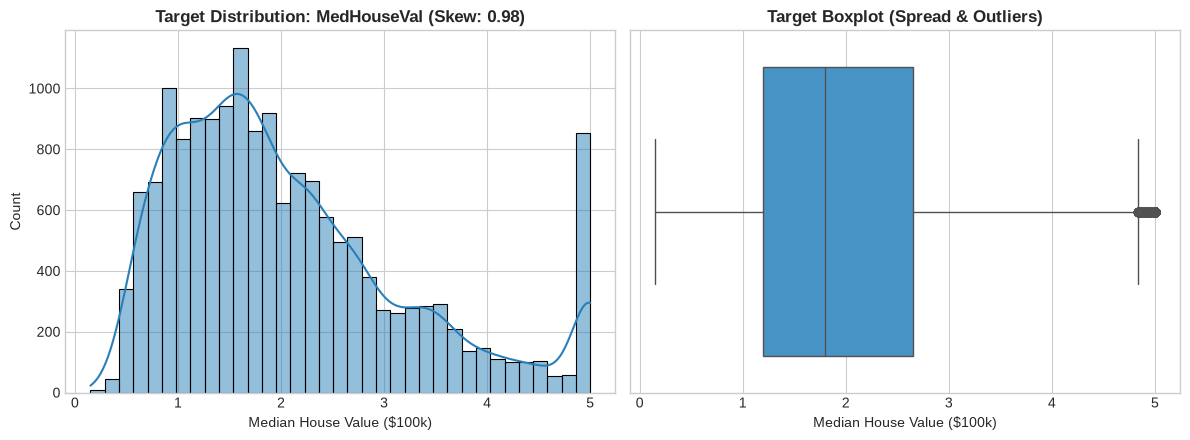

In [7]:
# ==============================================================================
# 🌐 STEP 6: TARGET ANALYSIS & TRANSFORMATION PROFILER
# ==============================================================================
def profile_target_distribution(y_original, y_transformed, target_name="MedHouseVal"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    
    sns.histplot(y_original, kde=True, ax=axes[0], color='#2980b9', bins=35)
    axes[0].set_title(f"Target Distribution: {target_name} (Skew: {y_original.skew():.2f})", fontweight='bold')
    axes[0].set_xlabel("Median House Value ($100k)")
    
    sns.boxplot(x=y_original, ax=axes[1], color='#3498db')
    axes[1].set_title(f"Target Boxplot (Spread & Outliers)", fontweight='bold')
    axes[1].set_xlabel("Median House Value ($100k)")
    
    plt.tight_layout()
    plt.show()

profile_target_distribution(y_train, y_train, target_name="MedHouseVal")


In [8]:
# ==============================================================================
# 🌐 STEP 7: UNIVERSAL MASTER COLUMNTRANSFORMER (ZERO DATA LEAKAGE)
# ==============================================================================
def build_universal_preprocessor(continuous_features, categorical_features):
    transformers = []
    if len(continuous_features) > 0:
        num_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())  # MANDATORY FOR DISTANCE-BASED REGRESSION!
        ])
        transformers.append(('num', num_pipeline, continuous_features))
        
    if len(categorical_features) > 0:
        cat_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
        transformers.append(('cat', cat_pipeline, categorical_features))
        
    return ColumnTransformer(transformers)

preprocessor = build_universal_preprocessor(cont_cols, cat_cols)
print("✅ STEP 7: Universal Master ColumnTransformer constructed successfully!")


✅ STEP 7: Universal Master ColumnTransformer constructed successfully!


In [9]:
# ==============================================================================
# 🧪 STEP 8: THE GEOMETRIC SCALING CATASTROPHE (UNSCALED VS SCALED KNN REGRESSOR)
# ==============================================================================
unscaled_transformers = []
if len(cont_cols) > 0:
    unscaled_num = Pipeline([('imputer', SimpleImputer(strategy='median'))])
    unscaled_transformers.append(('num', unscaled_num, cont_cols))
if len(cat_cols) > 0:
    unscaled_cat = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    unscaled_transformers.append(('cat', unscaled_cat, cat_cols))

unscaled_prep = ColumnTransformer(unscaled_transformers)

# 1. Unscaled KNN Regressor
knn_unscaled = Pipeline([('prep', unscaled_prep), ('knn', KNeighborsRegressor(n_neighbors=9))])
knn_unscaled.fit(X_train, y_train)
r2_unscaled = r2_score(y_test, knn_unscaled.predict(X_test))

# 2. Properly Scaled KNN Regressor
knn_scaled = Pipeline([('prep', preprocessor), ('knn', KNeighborsRegressor(n_neighbors=9, weights='distance'))])
knn_scaled.fit(X_train, y_train)
r2_scaled = r2_score(y_test, knn_scaled.predict(X_test))

print("=" * 70)
print("🧪 THE SCALING EXPERIMENT RESULTS (REGRESSION R²):")
print(f"   Unscaled Features R² : {r2_unscaled * 100:.2f}%")
print(f"   Properly Scaled R²   : {r2_scaled * 100:.2f}%")
print(f"   Net Gain from Scaling : {(r2_scaled - r2_unscaled) * 100:+.2f}% points")
print("=" * 70)


🧪 THE SCALING EXPERIMENT RESULTS (REGRESSION R²):
   Unscaled Features R² : 15.81%
   Properly Scaled R²   : 68.01%
   Net Gain from Scaling : +52.21% points


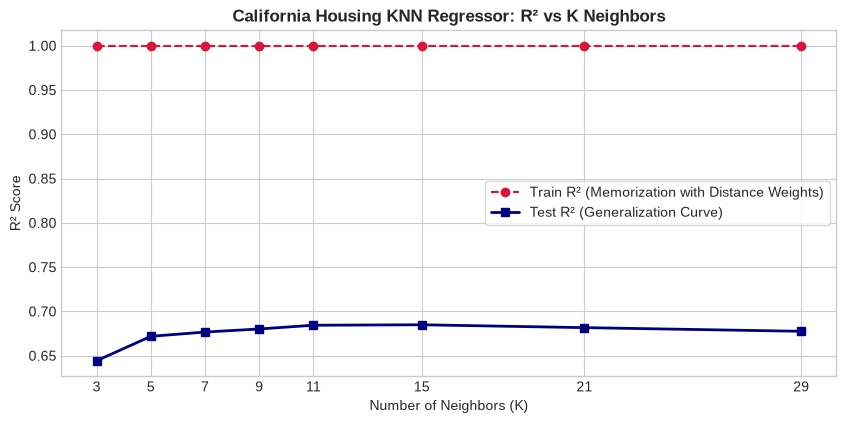

🏆 Best Cross-Validated Parameters: {'knn__n_neighbors': 9, 'knn__weights': 'distance'}
🎯 Best 3-Fold Cross-Validation R²: 69.20%


In [10]:
# ==============================================================================
# ⚙️ STEP 9: HYPERPARAMETER TUNING (K-CURVE & GRIDSEARCHCV)
# ==============================================================================
k_values = [3, 5, 7, 9, 11, 15, 21, 29]
train_r2, test_r2 = [], []

for k in k_values:
    pipe = Pipeline([('prep', preprocessor), ('knn', KNeighborsRegressor(n_neighbors=k, weights='distance', algorithm='ball_tree'))])
    pipe.fit(X_train, y_train)
    train_r2.append(r2_score(y_train, pipe.predict(X_train)))
    test_r2.append(r2_score(y_test, pipe.predict(X_test)))

plt.figure(figsize=(10, 4.5))
plt.plot(k_values, train_r2, 'o--', color='crimson', label='Train R² (Memorization with Distance Weights)')
plt.plot(k_values, test_r2, 's-', color='navy', label='Test R² (Generalization Curve)', linewidth=2)
plt.title("California Housing KNN Regressor: R² vs K Neighbors", fontsize=12, fontweight='bold')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("R² Score")
plt.xticks(k_values)
plt.legend(frameon=True)
plt.show()

# Grid Search across K and weights using Ball Tree optimization for speed
param_grid = {
    'knn__n_neighbors': [5, 9, 15, 21],
    'knn__weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(
    Pipeline([('prep', preprocessor), ('knn', KNeighborsRegressor(algorithm='ball_tree'))]),
    param_grid=param_grid,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_knn_model = grid_search.best_estimator_

print(f"🏆 Best Cross-Validated Parameters: {grid_search.best_params_}")
print(f"🎯 Best 3-Fold Cross-Validation R²: {grid_search.best_score_ * 100:.2f}%")


In [11]:
# ==============================================================================
# ⚔️ STEP 10: MULTI-MODEL BENCHMARK DUEL (KNN VS LINEAR VS RIDGE VS SGD)
# ==============================================================================
models = {
    "K-Nearest Neighbors (Tuned)": best_knn_model,
    "Linear Regression (OLS)": Pipeline([('prep', preprocessor), ('reg', LinearRegression())]),
    "Ridge Regression": Pipeline([('prep', preprocessor), ('reg', Ridge(alpha=10.0, random_state=42))]),
    "SGDRegressor": Pipeline([('prep', preprocessor), ('reg', SGDRegressor(loss='squared_error', penalty='l2', max_iter=2000, random_state=42))])
}

records = []
for name, model in models.items():
    t_start = time.perf_counter()
    if name != "K-Nearest Neighbors (Tuned)":
        model.fit(X_train, y_train)
    t_train_ms = (time.perf_counter() - t_start) * 1000
    
    t_inf_start = time.perf_counter()
    y_pred_real = model.predict(X_test)
    t_inf_ms = ((time.perf_counter() - t_inf_start) / len(X_test)) * 1000
    
    y_test_real = y_test.values
    r2 = r2_score(y_test_real, y_pred_real)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    
    records.append({
        "Model": name,
        "Test R² (%)": round(r2 * 100, 2),
        "MAE ($100k)": f"${mae:.3f}",
        "RMSE ($100k)": f"${rmse:.3f}",
        "Training Time (ms)": round(t_train_ms, 2),
        "Inference per Sample (ms)": round(t_inf_ms, 4)
    })

benchmark_df = pd.DataFrame(records).sort_values(by="Test R² (%)", ascending=False)
display(benchmark_df)


,Model,Test R² (%),MAE ($100k),RMSE ($100k),Training Time (ms),Inference per Sample (ms)
0,K-Nearest Neighbors (Tuned),68.01,$0.437,$0.647,0.00,0.0715
3,SGDRegressor,57.98,$0.530,$0.742,18.91,0.0007
2,Ridge Regression,57.61,$0.533,$0.745,13.30,0.0008
1,Linear Regression (OLS),57.58,$0.533,$0.746,16.34,0.0008


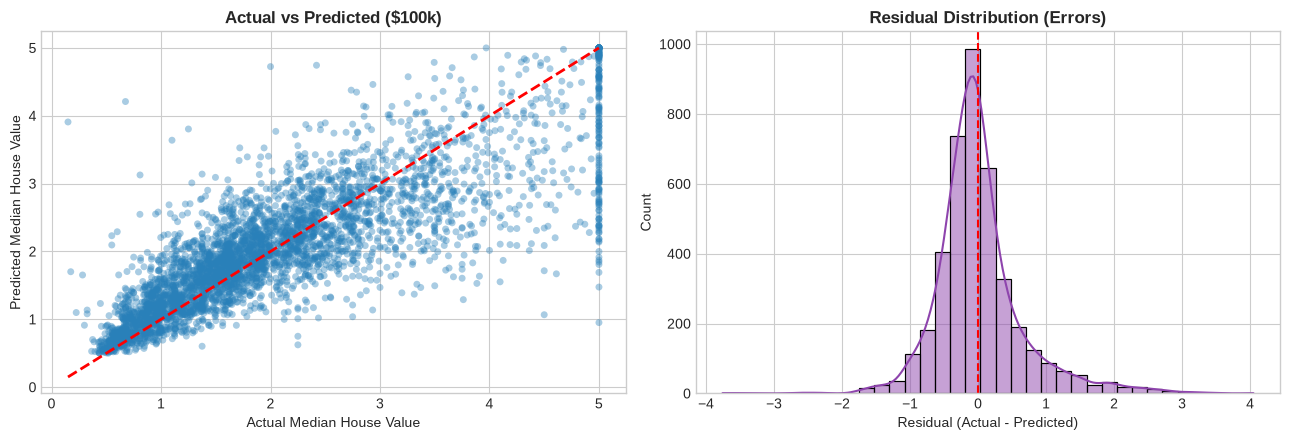

🎯 FINAL PRODUCTION KNN REGRESSOR METRICS:
   R² Score : 68.01%
   MAE      : $43,746.54
   RMSE     : $64,741.23


In [12]:
# ==============================================================================
# 📊 STEP 11: FINAL MODEL EVALUATION & RESIDUAL DIAGNOSTICS
# ==============================================================================
y_pred_real = best_knn_model.predict(X_test)
y_test_real = y_test.values
residuals = y_test_real - y_pred_real

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Actual vs Predicted
axes[0].scatter(y_test_real, y_pred_real, alpha=0.4, color='#2980b9', edgecolors='none', s=25)
min_v = min(y_test_real.min(), y_pred_real.min())
max_v = max(y_test_real.max(), y_pred_real.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2)
axes[0].set_title("Actual vs Predicted ($100k)", fontweight='bold')
axes[0].set_xlabel("Actual Median House Value")
axes[0].set_ylabel("Predicted Median House Value")

# 2. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='#8e44ad', bins=35)
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_title("Residual Distribution (Errors)", fontweight='bold')
axes[1].set_xlabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

final_r2 = r2_score(y_test_real, y_pred_real)
final_mae = mean_absolute_error(y_test_real, y_pred_real)
final_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print("=" * 70)
print(f"🎯 FINAL PRODUCTION KNN REGRESSOR METRICS:")
print(f"   R² Score : {final_r2 * 100:.2f}%")
print(f"   MAE      : ${final_mae * 100000:,.2f}")
print(f"   RMSE     : ${final_rmse * 100000:,.2f}")
print("=" * 70)


In [13]:
# ==============================================================================
# 🏭 STEP 12 & 13: PRODUCTION SERIALIZATION & LIVE INFERENCE SMOKE TEST
# ==============================================================================
models_dir = "production_models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "california_housing_knn_pipeline.joblib")

# 1. Serialization
joblib.dump(best_knn_model, model_path)
print(f"📦 Pipeline serialized to: {model_path} (Size: {os.path.getsize(model_path)/1024:.2f} KB)")

# 2. Live Smoke Test
loaded_model = joblib.load(model_path)
sample_dict = X_test.iloc[0].to_dict()
payload_df = pd.DataFrame([sample_dict])

t0 = time.perf_counter()
pred_value = loaded_model.predict(payload_df)[0]
latency_ms = (time.perf_counter() - t0) * 1000

print("\\n📡 Live Sample Payload (Dict):")
print(json.dumps({k: round(v, 4) for k, v in sample_dict.items()}, indent=2))
print(f"\\n🎯 PREDICTED VALUE : ${pred_value * 100000:,.2f} ({pred_value:.4f} units)")
print(f"   Actual Ground-Truth: ${y_test.iloc[0] * 100000:,.2f} ({y_test.iloc[0]:.4f} units)")
print(f"⏱️ Inference Latency: {latency_ms:.3f} ms (SLA < 10ms: {'PASS' if latency_ms < 10 else 'FLAG'})")
print("✅ ZERO-LEAKAGE PRODUCTION SMOKE TEST PASSED!")


📦 Pipeline serialized to: production_models/california_housing_knn_pipeline.joblib (Size: 2421.49 KB)
\n📡 Live Sample Payload (Dict):
{
  "MedInc": 1.6812,
  "HouseAge": 25.0,
  "AveRooms": 4.1922,
  "AveBedrms": 1.0223,
  "Population": 1392.0,
  "AveOccup": 3.8774,
  "Latitude": 36.06,
  "Longitude": -119.01
}
\n🎯 PREDICTED VALUE : $52,411.00 (0.5241 units)
   Actual Ground-Truth: $47,700.00 (0.4770 units)
⏱️ Inference Latency: 3.881 ms (SLA < 10ms: PASS)
✅ ZERO-LEAKAGE PRODUCTION SMOKE TEST PASSED!
